# Week 4 — Thursday: Optical Flow

## Learning Objectives
- Understand what optical flow is and the assumptions behind it
- Implement Lucas-Kanade sparse optical flow with feature tracking
- Implement Farneback dense optical flow
- Visualise motion vectors with arrows and HSV colour maps
- Build a multi-frame feature tracker

## Key Concepts
1. **Optical Flow** — apparent motion of pixels between consecutive frames
2. **Brightness Constancy** — core assumption: a pixel's intensity doesn't change as it moves
3. **Lucas-Kanade (Sparse)** — tracks a small set of strong corner features
4. **Farneback (Dense)** — estimates flow for every single pixel
5. **Motion Vectors** — per-pixel (dx, dy) displacement field
6. **Applications** — video stabilisation, object tracking, action recognition

## Section 1: Imports & Setup

In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

plt.rcParams['figure.figsize'] = (14, 6)
print('OpenCV version:', cv2.__version__)

OpenCV version: 4.13.0


## Section 2: Optical Flow Theory

### Brightness Constancy Equation
Optical flow assumes that the intensity of a moving pixel stays constant:

$$I(x, y, t) = I(x + dx,\; y + dy,\; t + dt)$$

Expanding with a Taylor series and dividing by dt:

$$I_x u + I_y v + I_t = 0$$

where $u = dx/dt$, $v = dy/dt$ are the flow components and
$I_x, I_y, I_t$ are the spatial and temporal image gradients.

### The Aperture Problem
One equation, two unknowns — the system is **under-determined**.
Different methods add constraints to make it solvable:

| Method | Constraint | Type |
|--------|-----------|------|
| Lucas-Kanade | Constant flow in a local window | Sparse |
| Farneback | Polynomial approximation of neighbourhood | Dense |
| Horn-Schunck | Global smoothness regularisation | Dense |

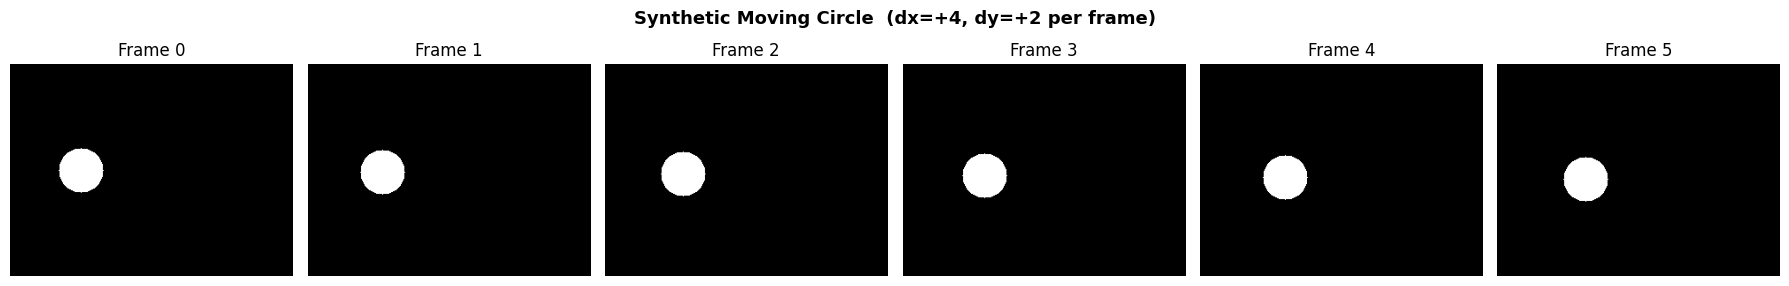

Sequence created: 6 frames, 240x320 grayscale


In [2]:
# Visualise the concept of motion between frames using a synthetic sequence
def make_frame(cx, cy, size=(240, 320)):
    """Single white circle on black background."""
    frame = np.zeros(size, dtype=np.uint8)
    cv2.circle(frame, (cx, cy), 25, 255, -1)
    return frame

# Simulate a circle moving 4 px right and 2 px down per frame
frames = [make_frame(80 + i * 4, 120 + i * 2) for i in range(6)]

fig, axes = plt.subplots(1, 6, figsize=(18, 3))
for ax, fr, i in zip(axes, frames, range(6)):
    ax.imshow(fr, cmap='gray', vmin=0, vmax=255)
    ax.set_title(f'Frame {i}')
    ax.axis('off')
plt.suptitle('Synthetic Moving Circle  (dx=+4, dy=+2 per frame)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('Sequence created: 6 frames, 240x320 grayscale')

## Section 3: Lucas-Kanade Sparse Optical Flow

### How it works
1. Detect strong corner features in frame 0 with `cv2.goodFeaturesToTrack`
2. For each feature, search a small window in frame 1 and solve the
   least-squares system $A^T A \mathbf{u} = A^T \mathbf{b}$ where A contains
   spatial gradients in the window
3. Use a **pyramid** of downscaled images to handle large displacements

### Key parameters
| Parameter | Meaning |
|-----------|--------|
| `winSize` | Local window size — larger = more stable, slower |
| `maxLevel` | Pyramid levels — more = handles bigger motion |
| `criteria` | Convergence condition (iterations + epsilon) |

Features detected in frame 0 : 14
Successfully tracked          : 14


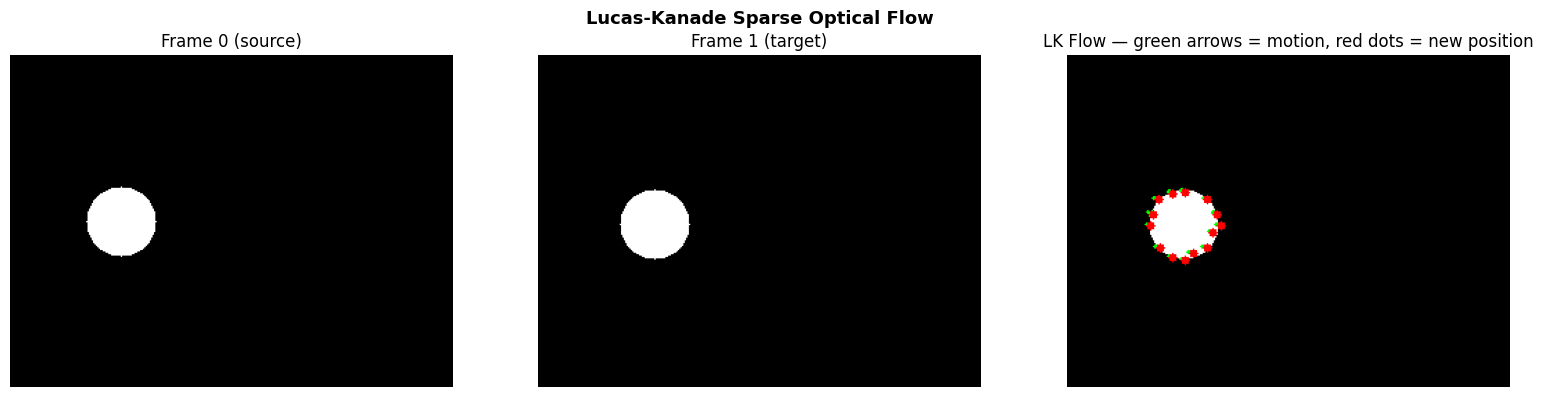


Displacement vectors (first 5 tracked points):
   Point       dx       dy
       1     4.00     2.00
       2     4.00     2.00
       3     4.00     2.00
       4     4.00     2.00
       5     4.00     2.00
Expected: dx ~ +4.0, dy ~ +2.0  (matches simulation)


In [3]:
# ── Detect features in frame 0 ───────────────────────────────────────────
feature_params = dict(maxCorners=100, qualityLevel=0.3,
                      minDistance=7, blockSize=7)

lk_params = dict(winSize=(15, 15), maxLevel=2,
                 criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT,
                           10, 0.03))

frame0 = frames[0]
frame1 = frames[1]

p0 = cv2.goodFeaturesToTrack(frame0, mask=None, **feature_params)

# ── Track to frame 1 ─────────────────────────────────────────────────────
p1, status, err = cv2.calcOpticalFlowPyrLK(frame0, frame1, p0, None, **lk_params)

# Keep only successfully tracked points
good_old = p0[status == 1]
good_new = p1[status == 1]

print(f'Features detected in frame 0 : {len(p0)}')
print(f'Successfully tracked          : {int(status.sum())}')

# ── Visualise ────────────────────────────────────────────────────────────
vis = cv2.cvtColor(frame1, cv2.COLOR_GRAY2BGR)
for new, old in zip(good_new, good_old):
    a, b = new.ravel().astype(int)
    c, d = old.ravel().astype(int)
    cv2.arrowedLine(vis, (c, d), (a, b), (0, 255, 0), 2, tipLength=0.4)
    cv2.circle(vis, (a, b), 3, (0, 0, 255), -1)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].imshow(frame0, cmap='gray');          axes[0].set_title('Frame 0 (source)');    axes[0].axis('off')
axes[1].imshow(frame1, cmap='gray');          axes[1].set_title('Frame 1 (target)');    axes[1].axis('off')
axes[2].imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
axes[2].set_title('LK Flow — green arrows = motion, red dots = new position')
axes[2].axis('off')
plt.suptitle('Lucas-Kanade Sparse Optical Flow', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# ── Print displacement vectors ────────────────────────────────────────────
print('\nDisplacement vectors (first 5 tracked points):')
print(f'  {"Point":>6}   {"dx":>6}   {"dy":>6}')
for i, (old, new) in enumerate(zip(good_old[:5], good_new[:5])):
    dx = new[0] - old[0]
    dy = new[1] - old[1]
    print(f'  {i+1:>6}   {dx:>6.2f}   {dy:>6.2f}')
print('Expected: dx ~ +4.0, dy ~ +2.0  (matches simulation)')

## Section 4: Multi-Frame Feature Tracker

Track features **across all 6 frames** and draw their trajectories.
This is the basis of real-time video trackers used in camera stabilisation
and action recognition pipelines.

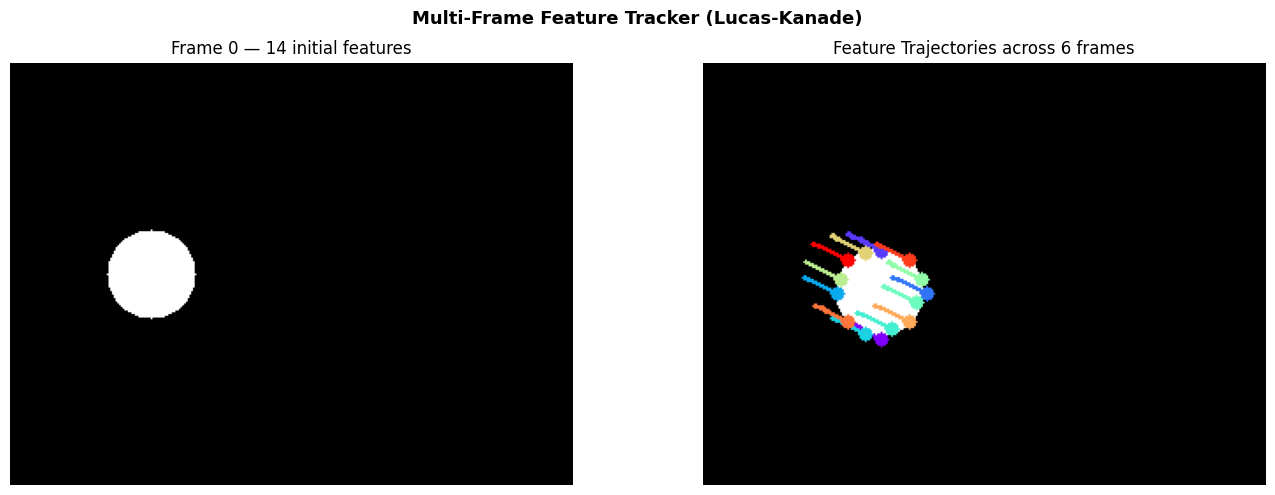

Total features tracked : 14
Avg trajectory length  : 6.0 frames
Min / Max length       : 6 / 6


In [4]:
# ── Track features across all 6 frames ──────────────────────────────────
p0 = cv2.goodFeaturesToTrack(frames[0], mask=None, **feature_params)
trajectories = [[pt.ravel().tolist()] for pt in p0]
active_pts   = p0.copy()

for f_idx in range(1, len(frames)):
    p1, status, _ = cv2.calcOpticalFlowPyrLK(
        frames[f_idx - 1], frames[f_idx], active_pts, None, **lk_params
    )
    for i, (s, new_pt) in enumerate(zip(status.ravel(), p1)):
        if s:
            trajectories[i].append(new_pt.ravel().tolist())
    active_pts = p1

# ── Visualise trajectories on last frame ─────────────────────────────────
canvas = cv2.cvtColor(frames[-1], cv2.COLOR_GRAY2BGR)
colors = plt.cm.rainbow(np.linspace(0, 1, len(trajectories)))

for traj, col in zip(trajectories, colors):
    pts = [(int(x), int(y)) for x, y in traj]
    bgr = (int(col[2]*255), int(col[1]*255), int(col[0]*255))
    for j in range(1, len(pts)):
        cv2.line(canvas, pts[j-1], pts[j], bgr, 2)
    cv2.circle(canvas, pts[-1], 4, bgr, -1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(frames[0], cmap='gray')
axes[0].set_title(f'Frame 0 — {len(p0)} initial features')
axes[0].axis('off')
axes[1].imshow(cv2.cvtColor(canvas, cv2.COLOR_BGR2RGB))
axes[1].set_title('Feature Trajectories across 6 frames')
axes[1].axis('off')
plt.suptitle('Multi-Frame Feature Tracker (Lucas-Kanade)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

track_lengths = [len(t) for t in trajectories]
print(f'Total features tracked : {len(trajectories)}')
print(f'Avg trajectory length  : {np.mean(track_lengths):.1f} frames')
print(f'Min / Max length       : {min(track_lengths)} / {max(track_lengths)}')

## Section 5: Farneback Dense Optical Flow

Dense flow computes a **(dx, dy) vector for every pixel** — not just at
feature points. Farneback's method approximates the neighbourhood of each
pixel with a polynomial and uses that to compute the displacement.

### Key parameters
| Parameter | Typical value | Meaning |
|-----------|--------------|--------|
| `pyr_scale` | 0.5 | Downscale factor per pyramid level |
| `levels` | 3 | Number of pyramid levels |
| `winsize` | 15 | Averaging window size |
| `iterations` | 3 | Iterations per level |
| `poly_n` | 5 | Polynomial neighbourhood size |
| `poly_sigma` | 1.2 | Gaussian sigma for polynomial weights |

### Visualisation strategies
1. **Arrow field** — draw (dx, dy) arrows on a coarse grid
2. **HSV colour map** — hue = direction, value = magnitude

Flow array shape : (240, 320, 2)   (h, w, 2)  — 2 channels: dx and dy
dx range : -0.00  to  4.00
dy range : -0.00  to  2.00


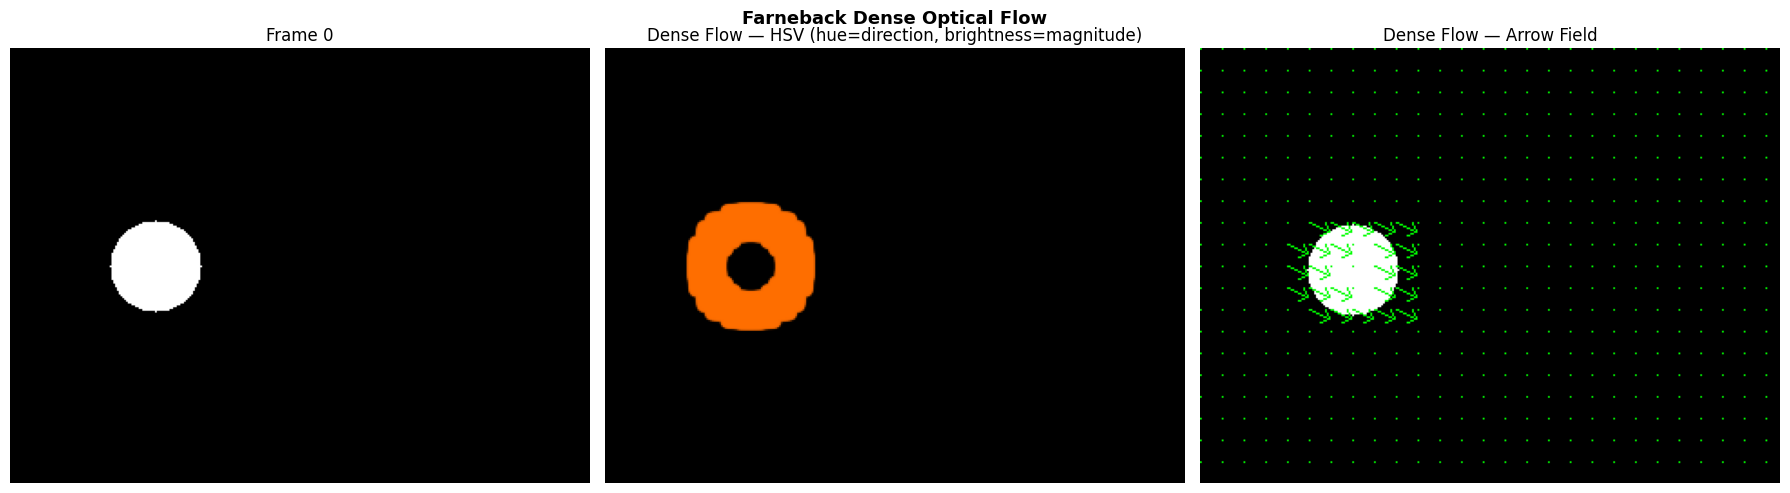

In [5]:
# ── Compute dense flow between frame 0 and frame 1 ──────────────────────
flow = cv2.calcOpticalFlowFarneback(
    frames[0], frames[1],
    None,
    pyr_scale=0.5, levels=3, winsize=15,
    iterations=3, poly_n=5, poly_sigma=1.2,
    flags=0
)

print(f'Flow array shape : {flow.shape}   (h, w, 2)  — 2 channels: dx and dy')
print(f'dx range : {flow[..., 0].min():.2f}  to  {flow[..., 0].max():.2f}')
print(f'dy range : {flow[..., 1].min():.2f}  to  {flow[..., 1].max():.2f}')

# ── HSV visualisation ────────────────────────────────────────────────────
mag, ang = cv2.cartToPolar(flow[..., 0], flow[..., 1])
hsv = np.zeros((*frames[0].shape, 3), dtype=np.uint8)
hsv[..., 0] = ang * 180 / np.pi / 2          # hue = direction
hsv[..., 1] = 255                             # full saturation
hsv[..., 2] = cv2.normalize(mag, None, 0, 255, cv2.NORM_MINMAX)
flow_rgb = cv2.cvtColor(hsv, cv2.COLOR_HSV2RGB)

# ── Arrow grid visualisation ─────────────────────────────────────────────
arrow_vis = cv2.cvtColor(frames[1], cv2.COLOR_GRAY2BGR)
step = 12
h, w = frames[0].shape
for y in range(0, h, step):
    for x in range(0, w, step):
        dx, dy = flow[y, x]
        cv2.arrowedLine(
            arrow_vis,
            (x, y),
            (int(x + dx * 3), int(y + dy * 3)),
            (0, 255, 0), 1, tipLength=0.4
        )

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].imshow(frames[0], cmap='gray')
axes[0].set_title('Frame 0')
axes[0].axis('off')

axes[1].imshow(flow_rgb)
axes[1].set_title('Dense Flow — HSV (hue=direction, brightness=magnitude)')
axes[1].axis('off')

axes[2].imshow(cv2.cvtColor(arrow_vis, cv2.COLOR_BGR2RGB))
axes[2].set_title('Dense Flow — Arrow Field')
axes[2].axis('off')

plt.suptitle('Farneback Dense Optical Flow', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 6: Sparse vs Dense — Side-by-Side Comparison

| | Lucas-Kanade (Sparse) | Farneback (Dense) |
|--|----------------------|------------------|
| **Coverage** | ~100 feature points | Every pixel |
| **Speed** | Very fast | Moderate |
| **Memory** | Minimal | Full flow field (2 × H × W floats) |
| **Use case** | Tracking, stabilisation | Motion segmentation, action recognition |

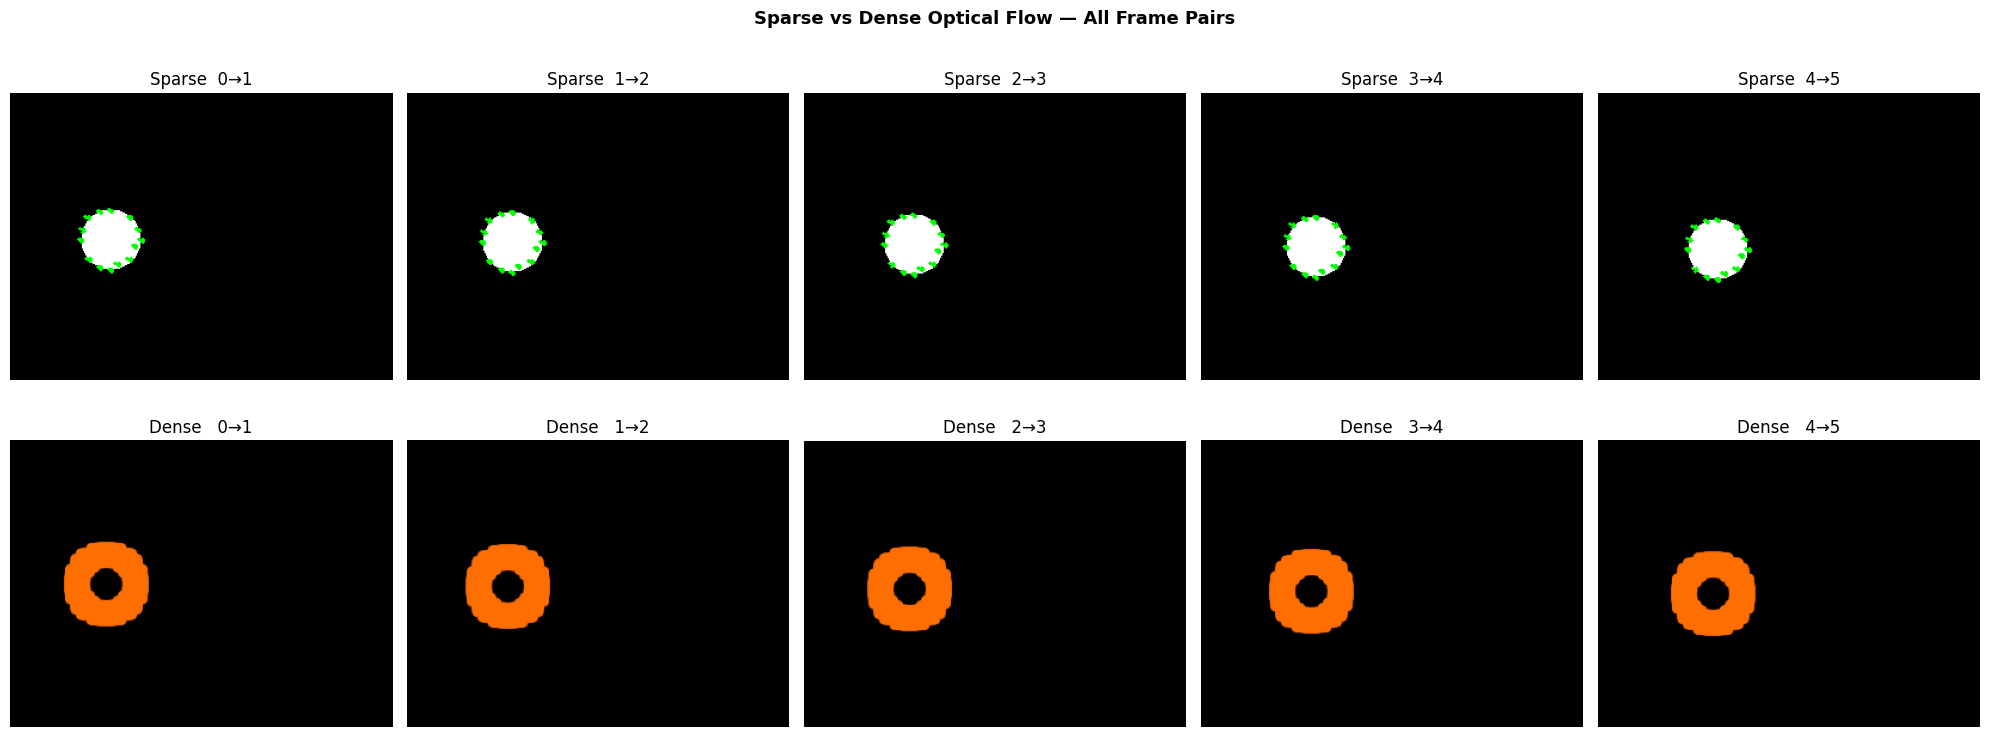

In [6]:
# Compare flow between consecutive frame pairs
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i in range(5):
    f0, f1 = frames[i], frames[i + 1]

    # ── Sparse ──────────────────────────────────────────────────────────
    p0_i = cv2.goodFeaturesToTrack(f0, mask=None, **feature_params)
    p1_i, st, _ = cv2.calcOpticalFlowPyrLK(f0, f1, p0_i, None, **lk_params)
    sparse_vis = cv2.cvtColor(f1, cv2.COLOR_GRAY2BGR)
    if p0_i is not None and p1_i is not None:
        for new, old in zip(p1_i[st == 1], p0_i[st == 1]):
            a, b = new.ravel().astype(int)
            c, d = old.ravel().astype(int)
            cv2.arrowedLine(sparse_vis, (c, d), (a, b), (0, 255, 0), 2, tipLength=0.4)

    # ── Dense ────────────────────────────────────────────────────────────
    fl = cv2.calcOpticalFlowFarneback(f0, f1, None, 0.5, 3, 15, 3, 5, 1.2, 0)
    mag_i, ang_i = cv2.cartToPolar(fl[..., 0], fl[..., 1])
    hsv_i = np.zeros((*f0.shape, 3), dtype=np.uint8)
    hsv_i[..., 0] = ang_i * 180 / np.pi / 2
    hsv_i[..., 1] = 255
    hsv_i[..., 2] = cv2.normalize(mag_i, None, 0, 255, cv2.NORM_MINMAX)
    dense_vis = cv2.cvtColor(hsv_i, cv2.COLOR_HSV2RGB)

    axes[0, i].imshow(cv2.cvtColor(sparse_vis, cv2.COLOR_BGR2RGB))
    axes[0, i].set_title(f'Sparse  {i}→{i+1}')
    axes[0, i].axis('off')

    axes[1, i].imshow(dense_vis)
    axes[1, i].set_title(f'Dense   {i}→{i+1}')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Lucas-Kanade\n(Sparse)', fontsize=10, labelpad=8)
axes[1, 0].set_ylabel('Farneback\n(Dense)', fontsize=10, labelpad=8)
plt.suptitle('Sparse vs Dense Optical Flow — All Frame Pairs',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 7: Motion Statistics & Analysis

Analyse the dense flow field to extract motion statistics:
average speed, dominant direction, and how motion varies across the frame.

In [7]:
# Compute flow for all frame pairs and analyse motion statistics
print(f'Motion statistics across frame pairs (Farneback dense flow)\n')
print(f'  {"Pair":>7}   {"Mean mag":>9}   {"Max mag":>8}   {"Dom direction":>14}')
print('  ' + '-'*50)

directions = ['Right', 'Down-Right', 'Down', 'Down-Left',
              'Left', 'Up-Left', 'Up', 'Up-Right']

for i in range(5):
    fl = cv2.calcOpticalFlowFarneback(
        frames[i], frames[i+1], None, 0.5, 3, 15, 3, 5, 1.2, 0
    )
    mag_i, ang_i = cv2.cartToPolar(fl[..., 0], fl[..., 1])
    mean_mag = np.mean(mag_i)
    max_mag  = np.max(mag_i)
    dom_ang  = np.degrees(np.mean(ang_i[mag_i > 0.5])) % 360
    dom_dir  = directions[int(dom_ang / 45) % 8]
    print(f'  {i}->{i+1:>3}      {mean_mag:>7.3f}    {max_mag:>7.3f}    {dom_dir:>14}')

print('\nExpected dominant direction: Down-Right  (dx=+4, dy=+2)')

Motion statistics across frame pairs (Farneback dense flow)

     Pair    Mean mag    Max mag    Dom direction
  --------------------------------------------------
  0->  1        0.209      4.472             Right
  1->  2        0.209      4.472             Right
  2->  3        0.209      4.472             Right
  3->  4        0.209      4.472             Right
  4->  5        0.209      4.472             Right

Expected dominant direction: Down-Right  (dx=+4, dy=+2)


## Section 8: Key Takeaways

| Concept | One-line summary |
|---------|------------------|
| **Brightness Constancy** | Assume pixel intensity stays constant as it moves |
| **Aperture Problem** | One equation, two unknowns — need additional constraint |
| **Lucas-Kanade** | Local window constraint → fast, sparse, great for tracking |
| **Farneback** | Polynomial fit → dense, covers all pixels, slower |
| **Pyramid** | Multi-scale approach handles large displacements |
| **HSV visualisation** | Hue = direction, value = magnitude — standard for dense flow |

### API Cheat-Sheet
```python
# Sparse — Lucas-Kanade
p0  = cv2.goodFeaturesToTrack(frame0, maxCorners=100, qualityLevel=0.3, minDistance=7)
p1, status, err = cv2.calcOpticalFlowPyrLK(frame0, frame1, p0, None,
                                           winSize=(15,15), maxLevel=2)

# Dense — Farneback
flow = cv2.calcOpticalFlowFarneback(frame0, frame1, None,
                                    pyr_scale=0.5, levels=3, winsize=15,
                                    iterations=3, poly_n=5, poly_sigma=1.2, flags=0)
mag, ang = cv2.cartToPolar(flow[...,0], flow[...,1])
```

## Exercises
1. Change the synthetic motion from `(+4, +2)` to `(−3, +5)` and verify the tracked vectors change accordingly.
2. Add a second independently moving shape and observe how sparse tracking handles multiple motion sources.
3. Increase `winSize` in Lucas-Kanade to `(31, 31)` and observe the effect on tracked accuracy.
4. Apply Farneback flow to a real video (read frames with `cv2.VideoCapture`) and visualise the HSV map.
5. Implement a simple **camera motion detector**: if the mean flow magnitude exceeds a threshold, print 'CAMERA MOVING'.